# AP 155 Lab Exercise
---
## Exercise 5: Derivatives (Second derivative and points on a grid)

_Instructions_: 
- **Report figure:**
    - Figure 1: First 5 eigenfunctions of a quantum harmonic oscillator.
    - Figure 2: Corresponding local kinetic energies (both approximation and analytical)
- **Report discussion:**
    - What is the significance of finite difference methods in numerical modeling?
    - For the central-difference calculation of local kinetic energy, how accurate is the numerical second derivative compared to the exact solution, what is the optimal step size, and how are edge points handled?
  
- **Code**: Complete the codes and ensure they are functional, error-free, readable, and efficient (where needed). Include a concise markdown documentation highlighting the critical steps of your algorithm for each problem.

### Student Information
- _Full Name (Last Name, First Name)_: 
- _Student No._: 20XX-XXXXX
- _Section_: THR-TX-_

### Grading Information (c/o Lab Instructor)
- [Rubrics description link](https://drive.google.com/file/d/1BMSlPot2Mc7XLu0eo4S8I8gLBsIadbCL/view?usp=sharing)

| Criteria | Score | Subtotal |
| --- | --- | --- |
| Report figure | XX | 20 |
| Report discussion | XX | 20|
| Code readability | XX | 20 |
| Code efficiency | XX | 20 | 
| Code appropriateness  | XX | 20 | 
| **TOTAL** | XXX | 100 |

_Date and Time Scored (MM/DD/YYYY HH:MM AM/PM):_:_

---
## Section 1: Report

### Report figure

<img src='figures/cat.jpg' width=45%> <img src='figures/cat.jpg' width=45%>

EDIT ME. See instruction above for what to include. Insert caption here, a short description what the figure illustrates. The syntax in markdown for putting a figure is `![Description](local_file_name.png)` or `<img src="/path/to_image.jpg" alt="Alt text" width=45%>`. Make sure the figure has complete elements.

### Report discussion

EDIT ME. See instruction above for what to include. Insert your discussions here. Discuss your key results with ~150 words per question.

### Other comments

- EDIT ME
- A self reflection can be placed here.
- This portion is not graded.
- You may insert further questions here.

---
## Section 2: Code

In [1]:
import numpy as np
import matplotlib.pyplot as plt

### Problem: Local kinetic energy in quantum mechanics

An important problem in one-dimensional single-particle quantum mechanics is the har-
monic oscillator; for this case, the time-independent Schr¨odinger equation takes the form:
$$ -\frac{\hbar^2}{2m} \frac{d^2 \psi(x)}{dx^2} + \frac{1}{2} m\omega^2 x^2  \psi(x) = E\psi(x) \tag{1} $$

where $\hbar$ is Planck’s constant (divided by $2\pi$) and the particle’s mass is $m$. The left-hand side
is made up of the kinetic energy (involving a second derivative) and the potential energy
(involving a term quadratic in $x$). The $\omega$ is the (classical) angular frequency.


Every quantum mechanics textbook discusses how to solve this problem. As you (may) have (already) learned in Physics 141, the energy eigenvalues and the normalized eigenfunctions are given by:
$$ E_n = \left(n + \frac{1}{2} \right) \hbar\omega \tag{2}$$

$$ \psi_n (x) = \frac{1}{\sqrt{2^n n!}} \left( \frac{m\omega}{\pi \hbar}\right)^{1/4} H_n \left(\sqrt{\frac{m\omega}{\hbar}} x\right) e^{-m\omega x^2/(2\hbar)} \tag{3}$$

where $n$ is a discrete index (a nonnegative integer) and $H_n(x)$ is the Hermite polynomial.

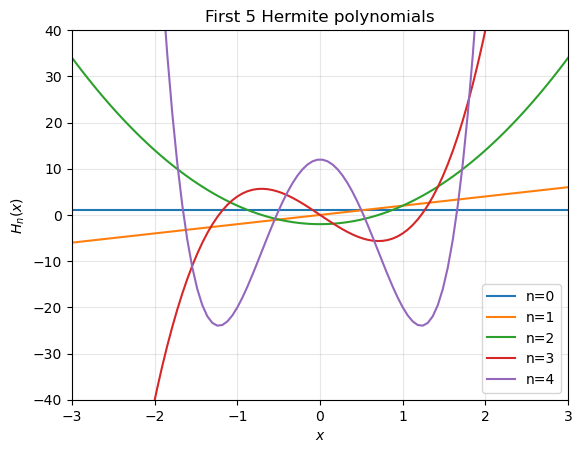

In [13]:
# the Hermite polynomial can be generated using a recurrence relation
# starting from the first two Hermite polynomials we can obtain any other Hermite polynomial with index n

import numpy as np
from scipy.special import factorial

def hermite(n, x):
    if n == 0:
        return np.ones_like(x, dtype=float), np.zeros_like(x, dtype=float)
    if n == 1:
        return 2.0 * x, 2.0 * np.ones_like(x, dtype=float)

    # for n>= 2
    val0 = np.ones_like(x, dtype=float)
    val1 = 2.0 * x
    for j in range(1, n):
        val2 = 2 * x * val1 - 2 * j * val0
        val0, val1 = val1, val2

    dval2 = 2 * n * val0
    return val2, dval2

xlist = np.linspace(-3,3,100)

fig, ax = plt.subplots()

for n in range(0, 5, 1):
    Hnlist, dHnlist = hermite(n, x=xlist)
    ax.plot(xlist, Hnlist, label=fr'n={n}')

ax.legend()
ax.set(xlabel=r'$x$', ylabel=r'$H_n(x)$', ylim=(-40,40), xlim=(-3,3), title='First 5 Hermite polynomials')
ax.grid(True, alpha=0.3)
plt.show()

(a) Create two functions, one that evaluates Eq. $(2)$ and another that evaluates Eq. $(3)$. Use the function above `hermite(n, x)` to evaluate the Hermite polynomial term in the eigenfunction equation. Set all the physical constants to $1$ for simplicity ($m=\hbar=\omega=1$).

In [2]:
def psiQHO(n, x, m=1, omega=1, hbar=1):
    """ """
    pass
    return 

def energyQHO():
    """ """
    pass
    return 

(b) **[FIGURE 1]** 
- Use your eigenfunction function to generate data for the first five quantum states ($n = 0, 1, 2, 3, 4$) using a 100-point spatial grid of $x_i$ from $x = -3$ to $x = 3$.
- Plot all five curves on a single set of axes.
- Shift each wavefunction vertically by adding its energy eigenvalue $E_n$ to the calculated $\psi(x_i)$ values.

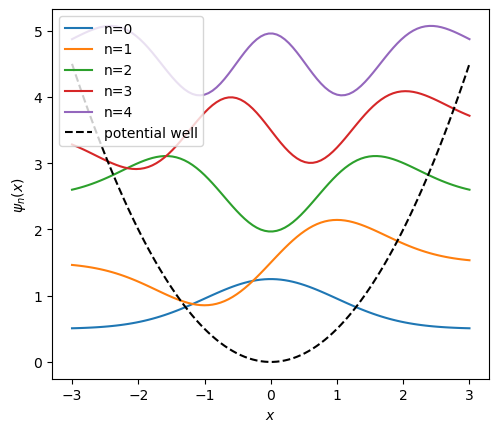

(c) Next, compute the particle's local kinetic energy $T_L$ using two different methods. First, write a function to calculate the exact analytical values across the domain $x \in [-3, 3]$ using the formula:
$$ T_L = \left( n + \frac{1}{2} \right)\hbar\omega - \frac{1}{2} m\omega^2 x^2.  \tag{4}$$
These results will serve as your analytical benchmark.

In [3]:
def analyticalT(n, x, hbar=1, omega=1, m=1):
    """ """
    pass
    return 

(d) **[FIGURE 2]** 
- Next, compute the local kinetic energy numerically using the operator definition:
$$T_L= \frac{\hat{T}\psi(x)}{\psi(x)} = \frac{1}{\psi(x)}\left[-\frac{\hbar^2}{2m}\frac{d\psi^2(x)}{dx}\right]. \tag{5}$$

- Write a function that evaluates the rightmost-hand side of Eq. (5) using the central-difference approximation on the spatial grid from part (b).

*Recall the central-difference formula:$$\frac{d^2 \psi(x)}{dx^2} \approx \frac{\psi(x+h) - 2\psi(x) + \psi(x-h)}{h^2}$$*

- Generate a plot that compares the analytical values of $T_L$ and the approximated values for $T_L$ for the first 5 levels.

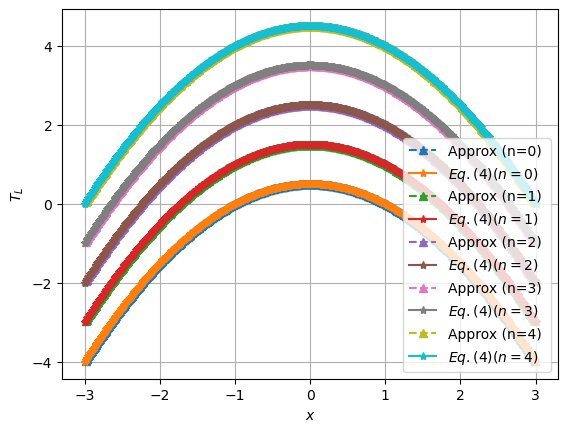

(e) Fixing the domain $x\in[-3,3]$, determine the optimal step size $h$ (or number of grid points $N$) that minimizes the error of the central-difference approximation for the second derivative. You may use the Mean Absolute Error (MAE) function from previous exercises to evaluate the accuracy.

#### Problem code summary

Include a summary at the bottom of your code outlining the purpose of the script and its core algorithm. Focus on explaining why you wrote the code this way and the reasoning behind your implementation choices.

---
## Section 3 (Notes)

### Points on a grid

#### Non-central difference formulas (First Derivative)

* Forward 
$$
f'(x_i) = \frac{f(x_{i+1}) - f(x_{x})}{h} + O(h)
$$

* Backward
$$
f'(x_i) = \frac{f(x_{i}) - f(x_{i-1})}{h} + O(h)
$$

#### Central-difference formulas

* First Derivative
$$
f'(x_i) = \frac{f(x_{i+1}) - f(x_{i-1})}{2h} + O(h^2)
$$

* Second Derivative
$$
f''(x_i) = \frac{f(x_{i+1}) - 2f(x_{i}) + f(x_{i-1})}{h^2} + O(h^2)
$$

Note: to avoid confusion, think: $x_i$ is `x[i]`, and $h$ is the gap between `x[i+1]` and `x[i]`.

### Others

In [13]:
## Useful tips. Not required to solve the problems below!

# Suppose you have a Numpy array
x = np.linspace(1, 10, 10)
print(x)

# I can move all values to the left/right using roll
x_roll = np.roll(x, 1) # change 1 to -1, what happens? 
x_roll2 = np.roll(x, -1)
print(x_roll)

# then I could exploit array operations to get their difference
x_diff = (x_roll - x)[1:]
print(x_diff)
# Be careful with the boundaries!

x_diff2 = (x_roll2 - x_roll)[:]
print(x_diff2)

[ 1.  2.  3.  4.  5.  6.  7.  8.  9. 10.]
[10.  1.  2.  3.  4.  5.  6.  7.  8.  9.]
[-1. -1. -1. -1. -1. -1. -1. -1. -1.]
[-8.  2.  2.  2.  2.  2.  2.  2.  2. -8.]


In [1]:
# finitediff.py from Gezerlis

from math import exp, sin, cos

def f(x):
    return exp(sin(2*x))

def fprime(x):
    return 2*exp(sin(2*x))*cos(2*x)

def calcfd(f,x,h):
    fd = (f(x+h) - f(x))/h
    return fd

def calccd(f,x,h):
    cd = (f(x+h/2) - f(x-h/2))/h
    return cd

if __name__ == '__main__':
    x = 0.5
    an = fprime(x)
    hs = [10**(-i) for i in range(1,12)]
    fds = [abs(calcfd(f,x,h) - an) for h in hs]
    cds = [abs(calccd(f,x,h) - an) for h in hs]
    rowf = "{0:1.0e}{1:1.16f} {2:1.16f}"
    print("h abs. error in fd abs. error in cd")
    for h,fd,cd in zip(hs,fds,cds):
        print(rowf.format(h,fd,cd))

h abs. error in fd abs. error in cd
1e-010.3077044583376249 0.0134656094697734
1e-020.0260359156900742 0.0001350472493096
1e-030.0025550421497806 0.0000013505116288
1e-040.0002550180941236 0.0000000135077878
1e-050.0000254969542519 0.0000000001495843
1e-060.0000025492660578 0.0000000002500959
1e-070.0000002564334673 0.0000000011382744
1e-080.0000000255070782 0.0000000189018428
1e-090.0000003741732106 0.0000000699159992
1e-100.0000021505300500 0.0000021505300500
1e-110.0000332367747395 0.0000111721462455


In [1]:
# richardsondiff.py

from finitediff import f, fprime, calcfd, calccd

x = 0.5
an = fprime(x)

hs = [10**(-i) for i in range(1,7)]

rowf = "{0:1.0e} {1:1.16f} {2:1.16f}"
print("h abs. err. rich fd abs. err. rich cd")

for h in hs:
    fdrich = 2*calcfd(f,x,h/2) - calcfd(f,x,h)
    fd = abs(fdrich-an)
    cdrich = (4*calccd(f,x,h/2) - calccd(f,x,h))/3
    cd = abs(cdrich-an)
    print(rowf.format(h,fd,cd))

h abs. err. rich fd abs. err. rich cd
1e-01 0.0259686059827384 0.0000098728370874
1e-02 0.0002695720500006 0.0000000009898602
1e-03 0.0000027005434182 0.0000000000011098
1e-04 0.0000000270109117 0.0000000000043667
1e-05 0.0000000003389138 0.0000000000280513
1e-06 0.0000000006941852 0.0000000002500959


### Worked example

Examine the derivative of a *noisy function* (e.g., from imperfectly measuring a
particle’s velocity $v_i$ at diﬀerent time slices $t_i$). Since we haven’t talked about random numbers yet, 
we will model the eﬀect of the noise by superimposing a highly oscillatory behavior on a slowly varying function. To make things concrete, let us study:
$$ f(x)= 2 + 5 \sin x + 0.1 \sin(30x)  $$

The last term has a small amplitude, but contains strong oscillations which have a dramatic eﬀect on the function’s derivative. Take 128 points placed on an equally spaced grid from $0$ to $2\pi$ and produce a table of values, ($x_i$, $f(x_i)$).

(a) Plot $f(x)$ together with $g(x)$, where $g(x)$ does not contain the third (highly oscillatory) term. Observe that the two curves basically lie on top of each other.

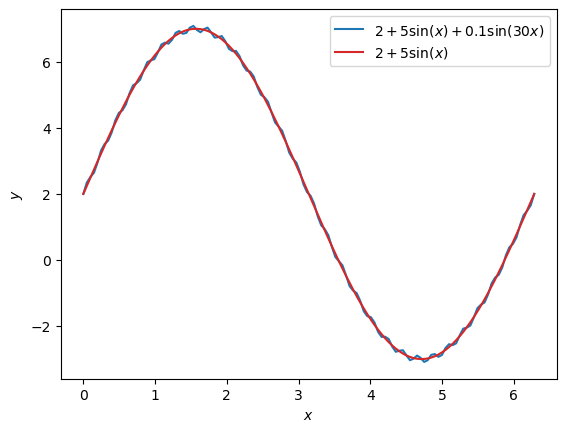

In [4]:
def f(x):
    """ 2 + 5sin(x) + 0.1sin(30x)"""
    return 2 + 5*np.sin(x) + 0.1*np.sin(30*x)

def g(x):
    """ 2 + 5sin(x) """
    return 2 + 5*np.sin(x)

xlist = np.linspace(0, 2*np.pi, 128)

fig, ax = plt.subplots()
ax.plot(xlist, f(xlist), c='tab:blue', label=r'$2 + 5\sin(x) + 0.1\sin(30x)$')
ax.plot(xlist, g(xlist), c='tab:red', label=r'$2 + 5\sin(x)$')
ax.set(xlabel=r'$x$', ylabel=r'$y$')
ax.legend()
plt.show()

(b) Create a plot that contains:
- (i) the analytically computed $f'(x)$,
- (ii) the analytically computed $g'(x)$, and
- (iii) the forward-diﬀerence approximation to $f'(x)$, using adjacent points on your grid.
- (iv) the forward-diﬀerence approximation to $f'(x)$, using grid points which are twice removed (e.g., to estimate the derivative at $x_{10}$ you use the function values at $x_{12}$ and $x_{10}$). Observe that this set of points exhibits "noise" with smaller amplitude; this is because we have employed a larger step size $h$ and have thereby smoothed out some of the
"unphysical" oscillations due to the third term. (Parts (b) and (c) are employing the forward-diﬀerence approximation, i.e., we were able to do a better job without turning to a better finite-diﬀerence approximation.)


In [5]:
xlist = np.linspace(0, 2*np.pi, 257)
ylist = f(xlist) 

# since evenly spaced points
h = xlist[1] - xlist[0]

ylistForwarded = np.roll(ylist, -1)
fd_approx = (ylistForwarded[:] - ylist[:])/h

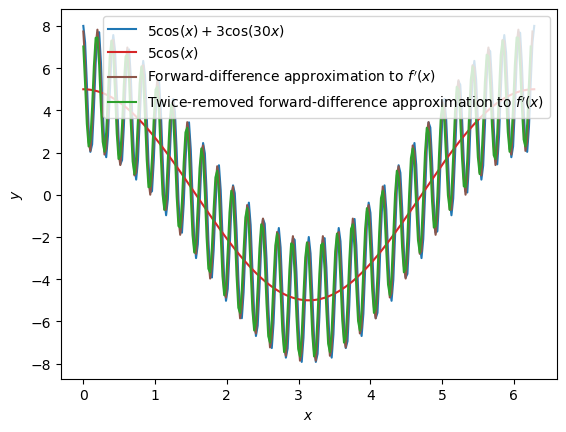

In [6]:
def fp(x):
    """ returns f'(x) = 5cos(x) + 3cos(30x) """
    return 5*np.cos(x) + 0.1*np.cos(30*x)*30

def gp(x):
    """ returns g'(x) = 5cos(x) """
    return 5*np.cos(x)

xlist = np.linspace(0, 2*np.pi, 257)
ylist = f(xlist) 

# since evenly spaced points
h = xlist[1] - xlist[0]

ylistForwarded = np.roll(ylist, -1)
fd_approx = (ylistForwarded[:-1] - ylist[:-1])/h

xlist = np.linspace(0, 2*np.pi, 257)
ylist = f(xlist) 

# twice-removed point
hTwice = xlist[2] - xlist[0]
fd_approxTwice = (ylist[2:] - ylist[:-2]) / hTwice

fig, ax = plt.subplots()
ax.plot(xlist, fp(xlist), c='tab:blue', label=r'$5\cos(x) + 3\cos(30x)$')
ax.plot(xlist, gp(xlist), c='tab:red', label=r'$5\cos(x)$')
ax.plot(xlist[:-1], fd_approx, c='tab:brown', label=r"Forward-difference approximation to $f'(x)$")
ax.plot(xlist[:-2], fd_approxTwice, c='tab:green', label=r"Twice-removed forward-difference approximation to $f'(x)$")
ax.set(xlabel=r'$x$', ylabel=r'$y$')
ax.legend()
plt.show()

(c) Create a plot that contains:
- (i) the analytically computed $f''(x)$,
- (ii) the central-diﬀerence approximation to the second derivative of $f(x)$ using the grid points $f(x_i)$.

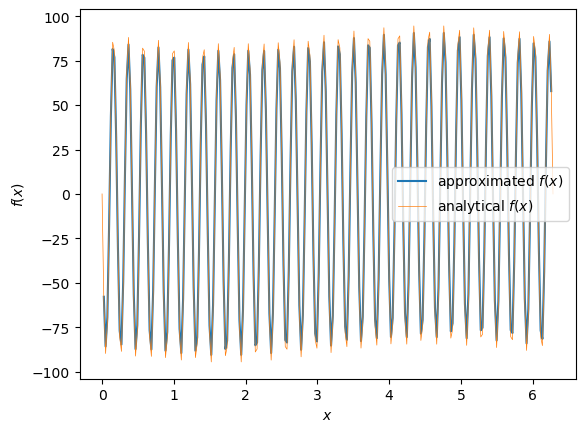

In [12]:
plt.plot(xlist[1:-1], (np.roll(ylist,-1) - 2*ylist + np.roll(ylist, 1))[1:-1]/(xlist[1]-xlist[0])**2, label=r'approximated $f''(x)$')
plt.plot(xlist, -5*np.sin(xlist) - 90*np.sin(xlist*30), lw=0.5, label=r'analytical $f''(x)$')
plt.legend()
plt.xlabel(r'$x$')
plt.ylabel(r'$f''(x)$')
plt.show()